# Exploración de Datos y Autoencoder

El presente cuaderno de trabajo tiene como objetivos principales:
1. Realizar la carga de los datos sintéticos de vibraciones.
2. Preprocesar las señales mediante la técnica de "ventaneado" (generación de secuencias temporales), permitiendo así al modelo extraer y aprender patrones dinámicos.
3. Entrenar un modelo basado en un Autoencoder Convolucional 1D empleando la biblioteca PyTorch, dada su idoneidad para el tratamiento de series temporales.

In [1]:
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config").is_dir() and (candidate / "app").is_dir():
            return candidate
    raise RuntimeError("No se ha podido localizar el directorio raíz de inference_server.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"REPO_ROOT={REPO_ROOT}")


REPO_ROOT=/workspace/TFM/inference_server


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Fijamos las semillas para garantizar la reproducibilidad de los experimentos.
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# Lectura de la configuración centralizada del sistema.
config_path = REPO_ROOT / "config" / "config.yaml"
with open(config_path, "r") as file:
    config = yaml.safe_load(file)

# Resolución de rutas relativas definidas en la configuración, ajustándolas a la raíz del repositorio.
for key in ["train_path", "test_normal_path", "test_anomaly_path"]:
    raw_path = Path(config["datos"][key])
    if not raw_path.is_absolute():
        raw_path = (REPO_ROOT / raw_path).resolve()
    config["datos"][key] = str(raw_path)

print("Configuración cargada exitosamente:")
print(yaml.dump(config, default_flow_style=False))


Configuración cargada:
data:
  sample_rate_hz: 50
  step: 50
  test_anomaly_path: /workspace/TFM/inference_server/datos/brutos/test_vibrations_anomaly.csv
  test_normal_path: /workspace/TFM/inference_server/datos/brutos/test_vibrations_normal.csv
  train_path: /workspace/TFM/inference_server/datos/brutos/train_vibrations_normal.csv
  window_size: 100
inference:
  min_anomaly_ratio: 0.02
  severe_threshold_multiplier: 3.0
  threshold: 0.005
  threshold_quantile: 0.999
logging:
  project_name: train-anomaly-detection
  run_name: run-10-threshold-0999
model:
  encoder_filters:
  - 16
  - 32
  - 64
  in_channels: 3
  kernel_size: 5
training:
  batch_size: 256
  epochs: 100
  learning_rate: 0.001
  seed: 42
  validation_split: 0.2



## 1. Carga y Preprocesamiento de Datos

En esta sección se procede a la ingestión del conjunto de datos y a su posterior estructuración en secuencias temporales. Teniendo en cuenta las especificaciones del hardware (frecuencia de muestreo de 100 Hz), se definirán ventanas de 1 segundo de duración, lo que equivale a 100 muestras por segmento.

In [4]:
def load_and_window_data(filepath, window_size=100, step=50):
    print(f"Iniciando la carga de datos desde: {filepath}")
    df = pd.read_csv(filepath)
    
    # Aislamiento de las componentes espaciales de la aceleración.
    features = df[['accel_x', 'accel_y', 'accel_z']].values
    
    min_vals = features.min(axis=0)
    max_vals = features.max(axis=0)
    features_norm = (features - min_vals) / (max_vals - min_vals)
    
    windows = []
    for i in range(0, len(features_norm) - window_size, step):
        windows.append(features_norm[i:i + window_size])
        
    windows = np.array(windows)
    windows = np.transpose(windows, (0, 2, 1))
    print(f"Dimensiones del tensor de secuencias resultante: {windows.shape}")
    return windows, min_vals, max_vals

data_path = config['data']['train_path']
w_size = config['data']['window_size']
step_size = config['data']['step']

X_train, min_v, max_v = load_and_window_data(data_path, window_size=w_size, step=step_size)

Cargando datos desde /workspace/TFM/inference_server/datos/brutos/train_vibrations_normal.csv...
Secuencias creadas: (14398, 3, 100)


In [5]:
class VibrationDataset(Dataset):
    def __init__(self, data):
        self.data = torch.FloatTensor(data)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.data[idx]

train_dataset = VibrationDataset(X_train)

b_size = config['training']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=b_size, shuffle=True)

## 2. Definición de la Arquitectura: Autoencoder Convolucional 1D

Se opta por una arquitectura basada en convoluciones unidimensionales (`Conv1d`) dada su probada eficacia para la extracción de características y el modelado de dependencias temporales locales (tales como las variaciones transitorias de alta frecuencia en la señal mecánica).

In [6]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self, in_channels=3, filters=[16, 32, 64], kernel_size=5):
        super(Conv1DAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, filters[0], kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv1d(filters[0], filters[1], kernel_size=kernel_size, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(filters[1], filters[2], kernel_size=kernel_size, stride=2, padding=2),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(filters[2], filters[1], kernel_size=kernel_size, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(filters[1], filters[0], kernel_size=kernel_size, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
        )
        
        self.final_conv = nn.Sequential(
             nn.ConvTranspose1d(filters[0], in_channels, kernel_size=7, stride=2, padding=3, output_padding=1),
             nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = self.final_conv(decoded)
        
        if decoded.size(2) != x.size(2):
             decoded = torch.nn.functional.interpolate(decoded, size=x.size(2))
             
        return decoded

# Instanciación del modelo aplicando los hiperparámetros configurados.
model = Conv1DAutoencoder(
    in_channels=config['model']['in_channels'],
    filters=config['model']['encoder_filters'],
    kernel_size=config['model']['kernel_size']
)
dummy_input = torch.randn(10, config['model']['in_channels'], config['data']['window_size'])
output = model(dummy_input)
print(f"Dimensiones del tensor de entrada: {dummy_input.shape} | Salida: {output.shape}")

Shape de entrada: torch.Size([10, 3, 100]), Shape de salida: torch.Size([10, 3, 100])


## 3. Proceso de Entrenamiento

Se procede al entrenamiento del modelo durante un número reducido de épocas, siendo esta configuración suficiente para validar la viabilidad y convergencia inicial del enfoque propuesto en esta fase exploratoria.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware de aceleración detectado: {device}")

model = model.to(device)
criterion = nn.MSELoss()

lr = config['training']['learning_rate']
epochs = config['training']['epochs']

optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_x)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_x.size(0)
        
    train_loss = train_loss / len(train_loader.dataset)
    print(f"Época {epoch+1}/{epochs} - Error de Reconstrucción (MSE): {train_loss:.6f}")

Usando dispositivo: cuda
Epoch 1/100 - Loss: 0.029992
Epoch 2/100 - Loss: 0.014496
Epoch 3/100 - Loss: 0.005062
Epoch 4/100 - Loss: 0.003874
Epoch 5/100 - Loss: 0.003567
Epoch 6/100 - Loss: 0.003385
Epoch 7/100 - Loss: 0.003240
Epoch 8/100 - Loss: 0.003130
Epoch 9/100 - Loss: 0.003046
Epoch 10/100 - Loss: 0.002981
Epoch 11/100 - Loss: 0.002948
Epoch 12/100 - Loss: 0.002918
Epoch 13/100 - Loss: 0.002878
Epoch 14/100 - Loss: 0.002853
Epoch 15/100 - Loss: 0.002823
Epoch 16/100 - Loss: 0.002829
Epoch 17/100 - Loss: 0.002786
Epoch 18/100 - Loss: 0.002755
Epoch 19/100 - Loss: 0.002734
Epoch 20/100 - Loss: 0.002702
Epoch 21/100 - Loss: 0.002687
Epoch 22/100 - Loss: 0.002652
Epoch 23/100 - Loss: 0.002598
Epoch 24/100 - Loss: 0.002570
Epoch 25/100 - Loss: 0.002518
Epoch 26/100 - Loss: 0.002491
Epoch 27/100 - Loss: 0.002449
Epoch 28/100 - Loss: 0.002471
Epoch 29/100 - Loss: 0.002405
Epoch 30/100 - Loss: 0.002419
Epoch 31/100 - Loss: 0.002397
Epoch 32/100 - Loss: 0.002372
Epoch 33/100 - Loss: 0.0

## Evaluación de Rendimiento Computacional (CPU vs. GPU)

El siguiente análisis cuantifica la aceleración computacional durante el entrenamiento al transicionar de un entorno CPU a uno GPU (mediante el entorno ROCm de AMD).

Se ejecutará sobre un subconjunto representativo de los datos para minimizar el tiempo de evaluación. Es pertinente notar que bajo PyTorch ROCm, la API subyacente para los dispositivos AMD sigue identificándose bajo la nomenclatura `cuda`.

In [8]:
import copy
import time

def benchmark_training_device(device_name, max_batches=30, warmup_batches=5):
    if device_name == "cuda" and not torch.cuda.is_available():
        print("Aceleración por hardware (CUDA/ROCm) no disponible. Omitiendo evaluación en GPU.")
        return None

    bench_device = torch.device(device_name)
    bench_model = Conv1DAutoencoder(
        in_channels=config["model"]["in_channels"],
        filters=config["model"]["encoder_filters"],
        kernel_size=config["model"]["kernel_size"],
    ).to(bench_device)
    bench_optimizer = optim.Adam(bench_model.parameters(), lr=config["training"]["learning_rate"])
    bench_criterion = nn.MSELoss()

    def sync():
        if bench_device.type == "cuda":
            torch.cuda.synchronize()

    bench_model.train()

    # Fase de calentamiento para mitigar los artefactos de medición derivados de la inicialización perezosa (lazy initialization) en la GPU.
    for idx, (batch_x, _) in enumerate(train_loader):
        if idx >= warmup_batches:
            break
        batch_x = batch_x.to(bench_device)
        bench_optimizer.zero_grad(set_to_none=True)
        outputs = bench_model(batch_x)
        loss = bench_criterion(outputs, batch_x)
        loss.backward()
        bench_optimizer.step()

    sync()
    start = time.perf_counter()
    batches = 0
    samples = 0
    losses = []

    for idx, (batch_x, _) in enumerate(train_loader):
        if idx >= max_batches:
            break
        batch_x = batch_x.to(bench_device)
        bench_optimizer.zero_grad(set_to_none=True)
        outputs = bench_model(batch_x)
        loss = bench_criterion(outputs, batch_x)
        loss.backward()
        bench_optimizer.step()
        batches += 1
        samples += batch_x.size(0)
        losses.append(float(loss.detach().cpu()))

    sync()
    elapsed = time.perf_counter() - start
    result = {
        "device": device_name,
        "batches": batches,
        "samples": samples,
        "seconds": elapsed,
        "seconds_per_batch": elapsed / batches if batches else None,
        "samples_per_second": samples / elapsed if elapsed else None,
        "mean_loss": float(np.mean(losses)) if losses else None,
    }
    print(result)
    return result

cpu_result = benchmark_training_device("cpu")
gpu_result = benchmark_training_device("cuda")

if cpu_result and gpu_result:
    speedup = cpu_result["seconds"] / gpu_result["seconds"]
    print(f"Factor de aceleración (Speedup) GPU vs CPU: {speedup:.2f}x")


{'device': 'cpu', 'batches': 30, 'samples': 7680, 'seconds': 0.25619650900625857, 'seconds_per_batch': 0.008539883633541951, 'samples_per_second': 29976.989264176067, 'mean_loss': 0.031038696691393853}
{'device': 'cuda', 'batches': 30, 'samples': 7680, 'seconds': 0.638792329998978, 'seconds_per_batch': 0.021293077666632597, 'samples_per_second': 12022.686621820096, 'mean_loss': 0.036240069878598055}
Speedup GPU vs CPU: 0.40x


## Análisis de Sensibilidad Computacional respecto al Tamaño de Lote (Batch Size)

La evaluación anterior empleó la configuración estática definida en el archivo general. Debido a la reducida complejidad paramétrica del modelo, la latencia inducida por la transferencia de memoria puede penalizar el rendimiento de la GPU.

El siguiente experimento analiza empíricamente cómo el incremento del tamaño de lote altera la carga de trabajo por iteración, determinando así el régimen en el que la paralelización masiva de la GPU mitiga eficazmente el coste de su inicialización.

,batch_size,cpu_seconds,cpu_samples_per_second,gpu_seconds,gpu_samples_per_second,gpu_speedup
0,128,0.202930,25230.388806,0.415130,12333.475438,0.488834
1,256,0.308794,33161.230219,0.796201,12861.066046,0.387834
2,512,0.331503,43432.515304,1.093299,13169.320167,0.303213
3,1024,0.315907,45576.715068,1.096630,13129.315336,0.288071
4,2048,0.322249,44679.717627,1.095390,13144.175748,0.294187
5,4096,0.437949,32876.008825,1.110133,12969.619362,0.394501


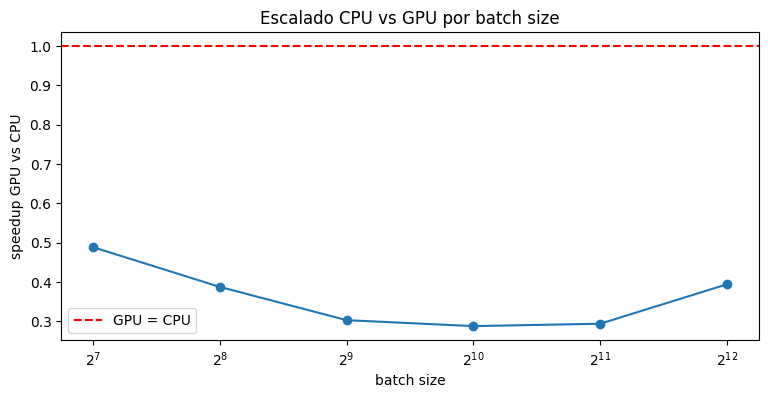

In [10]:
from torch.utils.data import DataLoader

def benchmark_training_device_with_loader(device_name, loader, max_batches=40, warmup_batches=5):
    if device_name == "cuda" and not torch.cuda.is_available():
        return None

    bench_device = torch.device(device_name)
    bench_model = Conv1DAutoencoder(
        in_channels=config["model"]["in_channels"],
        filters=config["model"]["encoder_filters"],
        kernel_size=config["model"]["kernel_size"],
    ).to(bench_device)
    bench_optimizer = optim.Adam(bench_model.parameters(), lr=config["training"]["learning_rate"])
    bench_criterion = nn.MSELoss()

    def sync():
        if bench_device.type == "cuda":
            torch.cuda.synchronize()

    bench_model.train()

    for idx, (batch_x, _) in enumerate(loader):
        if idx >= warmup_batches:
            break
        batch_x = batch_x.to(bench_device)
        bench_optimizer.zero_grad(set_to_none=True)
        loss = bench_criterion(bench_model(batch_x), batch_x)
        loss.backward()
        bench_optimizer.step()

    sync()
    start = time.perf_counter()
    batches = 0
    samples = 0

    for idx, (batch_x, _) in enumerate(loader):
        if idx >= max_batches:
            break
        batch_x = batch_x.to(bench_device)
        bench_optimizer.zero_grad(set_to_none=True)
        loss = bench_criterion(bench_model(batch_x), batch_x)
        loss.backward()
        bench_optimizer.step()
        batches += 1
        samples += batch_x.size(0)

    sync()
    elapsed = time.perf_counter() - start
    return {
        "device": device_name,
        "batches": batches,
        "samples": samples,
        "seconds": elapsed,
        "seconds_per_batch": elapsed / batches if batches else np.nan,
        "samples_per_second": samples / elapsed if elapsed else np.nan,
    }

batch_sizes = [128, 256, 512, 1024, 2048, 4096]
rows = []

for batch_size in batch_sizes:
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    cpu = benchmark_training_device_with_loader("cpu", loader)
    gpu = benchmark_training_device_with_loader("cuda", loader)

    row = {"batch_size": batch_size}
    if cpu:
        row["cpu_seconds"] = cpu["seconds"]
        row["cpu_samples_per_second"] = cpu["samples_per_second"]
    if gpu:
        row["gpu_seconds"] = gpu["seconds"]
        row["gpu_samples_per_second"] = gpu["samples_per_second"]
    if cpu and gpu:
        row["gpu_speedup"] = cpu["seconds"] / gpu["seconds"]
    rows.append(row)

benchmark_df = pd.DataFrame(rows)
display(benchmark_df)

if "gpu_speedup" in benchmark_df:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(benchmark_df["batch_size"], benchmark_df["gpu_speedup"], marker="o")
    ax.axhline(1.0, color="red", linestyle="--", label="Igualdad de Rendimiento (GPU = CPU)")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Tamaño de lote (batch size)")
    ax.set_ylabel("Aceleración GPU respecto a CPU")
    ax.set_title("Análisis de Escalabilidad Arquitectónica en Función del Tamaño de Lote")
    ax.legend()
    plt.show()


## 4. Análisis Cualitativo de la Reconstrucción

A continuación, se verifica gráficamente la capacidad del Autoencoder para reproducir la morfología temporal de las series correspondientes al régimen nominal de operación.

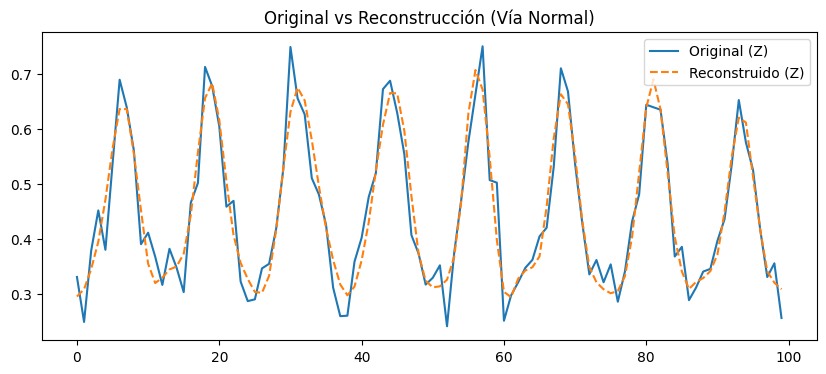

In [9]:
model.eval()
sample = train_dataset[0][0].unsqueeze(0).to(device)
with torch.no_grad():
    reconstruction = model(sample)

# Transferencia del tensor resultante a la memoria principal (CPU) para su visualización.
orig_z = sample[0, 2, :].cpu().numpy()
recon_z = reconstruction[0, 2, :].cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(orig_z, label="Señal Original (Eje Z)")
plt.plot(recon_z, label="Señal Reconstruida (Eje Z)", linestyle='--')
plt.title("Comparativa de Reconstrucción en Régimen Nominal")
plt.legend()
plt.show()